In [15]:
!unzip -uq "/content/test.zip" -d "/content"

In [2]:
!pip install torch transformers pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from collections import Counter
import json
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Setup Complete. Using Device: {device}")

✅ Setup Complete. Using Device: cpu


In [3]:
class SimpleTokenizer:
    def __init__(self, jsonl_path):

        self.word2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}

        print("📖 Scanning text data to learn words...")
        with open(jsonl_path, 'r') as f:
            for line in f:
                entry = json.loads(line)

                text = entry['cot'].lower().replace(".", " .").replace(",", " ,").replace(":", " :")
                for word in text.split():
                    if word not in self.word2idx:
                        idx = len(self.word2idx)
                        self.word2idx[word] = idx
                        self.idx2word[idx] = word

        print(f"✅ Vocabulary Built! Found {len(self.word2idx)} unique words.")

    def encode(self, text):
        # Text -> Numbers
        text = text.lower().replace(".", " .").replace(",", " ,").replace(":", " :")
        tokens = ["<SOS>"] + text.split() + ["<EOS>"]
        return [self.word2idx.get(w, 3) for w in tokens]

    def decode(self, token_ids):

        words = []
        for idx in token_ids:
            if idx == 2: break
            if idx not in [0, 1, 2]:
                words.append(self.idx2word.get(idx, "<UNK>"))
        return " ".join(words)


jsonl_path = "/content/plant_data/data.jsonl"
tokenizer = SimpleTokenizer(jsonl_path)

📖 Scanning text data to learn words...
✅ Vocabulary Built! Found 374 unique words.


In [4]:

class PlantGenDataset(Dataset):
    def __init__(self, jsonl_path, root_dir, tokenizer, processor):
        self.root_dir = root_dir
        self.tokenizer = tokenizer
        self.processor = processor
        self.data = [json.loads(line) for line in open(jsonl_path, 'r')]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]


        img_path = os.path.join(self.root_dir, item['image'])
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new('RGB', (224, 224), color='black')

        inputs = self.processor(text=item['question'], images=image, return_tensors="pt", padding="max_length", truncation=True)


        target_ids = self.tokenizer.encode(item['cot'])

        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'target_ids': torch.tensor(target_ids, dtype=torch.long)
        }

def collate_fn(batch):

    pix = torch.stack([x['pixel_values'] for x in batch])
    ids = torch.stack([x['input_ids'] for x in batch])
    mask = torch.stack([x['attention_mask'] for x in batch])


    targets = [x['target_ids'] for x in batch]
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=0)

    return pix, ids, mask, targets_padded

print("📦 Loading Dataset...")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
dataset = PlantGenDataset(jsonl_path, "/content/plant_data/", tokenizer, processor)

train_loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
print(f"✅ Dataset Ready: {len(dataset)} examples.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


📦 Loading Dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

✅ Dataset Ready: 74 examples.


In [5]:
class RecursiveReasoningLayer(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_steps=5):
        super().__init__()
        self.num_steps = num_steps
        self.gru = nn.GRUCell(input_dim, hidden_dim)

    def forward(self, x):
        batch_size = x.size(0)
        hidden = torch.zeros(batch_size, self.gru.hidden_size).to(x.device)
        for _ in range(self.num_steps):
            hidden = self.gru(x, hidden)
        return hidden

class PlantGenerator(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        # 1. The Eye (CLIP)
        self.clip = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        for p in self.clip.parameters(): p.requires_grad = False # Freeze CLIP

        # 2. The Thinker (TRM)
        # Input: 512 (Image) + 512 (Text) = 1024. Output: 512
        self.reasoning = RecursiveReasoningLayer(1024, 512)

        # 3. The Writer (Decoder)
        self.embedding = nn.Embedding(vocab_size, 256)

        # Input to RNN: Word Embedding (256) + Image Context (512) = 768
        self.decoder = nn.GRU(256 + 512, 512, batch_first=True)
        self.fc_out = nn.Linear(512, vocab_size)

    def forward(self, pix, ids, mask, target_ids):
        # A. Encode
        with torch.no_grad():
            img_f = self.clip.get_image_features(pix)
            txt_f = self.clip.get_text_features(ids, mask)
        combined = torch.cat((img_f, txt_f), dim=1)

        # B. Reason
        context = self.reasoning(combined) # [Batch, 512]

        # C. Decode (Teacher Forcing)
        # Prepare words
        embeds = self.embedding(target_ids) # [Batch, Seq, 256]

        # Expand Context to match sequence length
        seq_len = embeds.size(1)
        context_expanded = context.unsqueeze(1).repeat(1, seq_len, 1) # [Batch, Seq, 512]

        # Feed BOTH Word and Context to the RNN
        rnn_input = torch.cat((embeds, context_expanded), dim=2)

        rnn_out, _ = self.decoder(rnn_input, context.unsqueeze(0))
        return self.fc_out(rnn_out)

    def generate(self, pix, ids, mask, max_len=60):
        # Inference Mode (One word at a time)
        with torch.no_grad():
            img_f = self.clip.get_image_features(pix)
            txt_f = self.clip.get_text_features(ids, mask)
            context = self.reasoning(torch.cat((img_f, txt_f), dim=1))

            # Start with <SOS>
            curr_token = torch.tensor([[1]]).to(pix.device)
            hidden = context.unsqueeze(0)
            generated_ids = []

            for _ in range(max_len):
                embed = self.embedding(curr_token) # [1, 1, 256]

                # Expand context for this single step
                context_step = context.unsqueeze(1) # [1, 1, 512]

                # Combine
                rnn_input = torch.cat((embed, context_step), dim=2)

                out, hidden = self.decoder(rnn_input, hidden)
                logit = self.fc_out(out)

                next_id = torch.argmax(logit, dim=2)
                generated_ids.append(next_id.item())

                if next_id.item() == 2: break # Stop at <EOS>
                curr_token = next_id

            return generated_ids

model = PlantGenerator(len(tokenizer.word2idx)).to(device)
print("✅ Model Architecture Created.")

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

✅ Model Architecture Created.


In [6]:
# Block 5: Training Loop

optimizer = optim.Adam(model.parameters(), lr=0.0005) # Slightly higher LR for faster start
criterion = nn.CrossEntropyLoss(ignore_index=0) # Ignore <PAD>

print("🚀 Starting Training...")
model.train()

epochs = 30 # Set this high enough for the model to learn

for epoch in range(epochs):
    total_loss = 0
    for step, batch in enumerate(train_loader):
        pix, ids, mask, targets = [x.to(device) for x in batch]

        optimizer.zero_grad()

        # Teacher Forcing: Input is "A B C", Target is "B C D"
        # We pass full targets, but forward() usually handles shifting or we slice here
        # For simplicity in this architecture, we predict the NEXT word given current

        # We feed (S0, S1, S2...) and try to predict (S1, S2, S3...)
        inputs_seq = targets[:, :-1]
        targets_seq = targets[:, 1:]

        logits = model(pix, ids, mask, inputs_seq)

        # Flatten for Loss calculation
        loss = criterion(logits.reshape(-1, logits.size(-1)), targets_seq.reshape(-1))

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

print("🎉 Training Finished!")

🚀 Starting Training...
Epoch 1/30 | Loss: 5.6048
Epoch 2/30 | Loss: 4.6784
Epoch 3/30 | Loss: 4.2762
Epoch 4/30 | Loss: 3.9613
Epoch 5/30 | Loss: 3.7170
Epoch 6/30 | Loss: 3.4771
Epoch 7/30 | Loss: 3.2727
Epoch 8/30 | Loss: 3.1336
Epoch 9/30 | Loss: 2.9709
Epoch 10/30 | Loss: 2.9408
Epoch 11/30 | Loss: 2.7268
Epoch 12/30 | Loss: 2.7017
Epoch 13/30 | Loss: 2.5266
Epoch 14/30 | Loss: 2.4622
Epoch 15/30 | Loss: 2.3180
Epoch 16/30 | Loss: 2.1648
Epoch 17/30 | Loss: 2.1535
Epoch 18/30 | Loss: 2.0777
Epoch 19/30 | Loss: 1.9970
Epoch 20/30 | Loss: 1.9181
Epoch 21/30 | Loss: 1.8376
Epoch 22/30 | Loss: 1.7570
Epoch 23/30 | Loss: 1.7013
Epoch 24/30 | Loss: 1.6076
Epoch 25/30 | Loss: 1.5492
Epoch 26/30 | Loss: 1.4231
Epoch 27/30 | Loss: 1.4071
Epoch 28/30 | Loss: 1.3960
Epoch 29/30 | Loss: 1.3167
Epoch 30/30 | Loss: 1.2485
🎉 Training Finished!


In [8]:
# Block 6: Test the Model

model.eval()

# Pick Random Sample
idx = random.randint(0, len(dataset)-1)
sample = dataset[idx]

# Prepare Inputs
pix = sample['pixel_values'].unsqueeze(0).to(device)
ids = sample['input_ids'].unsqueeze(0).to(device)
mask = sample['attention_mask'].unsqueeze(0).to(device)

# Generate Text
print
print(f"🖼️ Question: {dataset.data[idx]['question']}")
print(f"📝 True CoT: {dataset.data[idx]['cot']}")
print("-" * 50)

output_ids = model.generate(pix, ids, mask)
generated_text = tokenizer.decode(output_ids)

print(f"🤖 Model Says: {generated_text}")

🖼️ Question: Can you observe disease-caused abnormalities?
📝 True CoT: Step 1: The annotation indicates abnormalities are present.
Step 2: These abnormalities are attributed to spider mite infestation.
Step 3: Such pest-induced changes classify the leaf as unhealthy.
Conclusion: Yes, abnormalities are observed.
--------------------------------------------------
🤖 Model Says: step 1 : the annotation states that the leaf shows large , dark , water-soaked lesions . step 2 : these symptoms are present . step 3 : these observations support a healthy classification . conclusion : the plant is tomato .


In [12]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 15.5 MB/s eta 0:00:00


In [13]:
import torch
from torchmetrics.text import BLEUScore, ROUGEScore
from tqdm import tqdm # Progress bar

def evaluate_model(model, dataloader, tokenizer, device):
    print("📊 Starting Evaluation... (This may take time)")
    model.eval()

    # Initialize Metrics
    bleu = BLEUScore().to(device)
    rouge = ROUGEScore().to(device)

    predictions = []
    references = []
    total_loss = 0
    criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

    # We use 'no_grad' to speed up and save memory
    with torch.no_grad():
        for batch in tqdm(dataloader):
            pix, ids, mask, targets = [x.to(device) for x in batch]

            # 1. Calculate Loss (Perplexity)
            # We feed inputs to get logits
            logits = model(pix, ids, mask, targets[:, :-1])
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets[:, 1:].reshape(-1))
            total_loss += loss.item()

            # 2. Generate Text for Metrics
            # We must run .generate() to see what the model actually writes
            # (We process batch one by one for generation to keep code simple)
            for i in range(pix.size(0)):
                # Get single item
                p = pix[i].unsqueeze(0)
                i_d = ids[i].unsqueeze(0)
                m = mask[i].unsqueeze(0)

                # Generate
                gen_ids = model.generate(p, i_d, m)
                gen_text = tokenizer.decode(gen_ids)

                # Get Truth
                true_ids = targets[i].tolist()
                true_text = tokenizer.decode(true_ids)

                predictions.append(gen_text)
                references.append(true_text)

    # Calculate Final Scores
    avg_loss = total_loss / len(dataloader)
    bleu_score = bleu(predictions, references).item()
    rouge_scores = rouge(predictions, references)

    print("\n" + "="*30)
    print(f"📉 Test Loss:      {avg_loss:.4f}")
    print(f"🔵 BLEU Score:     {bleu_score:.4f} (Higher is better, Max 1.0)")
    print(f"🔴 ROUGE-L Score:  {rouge_scores['rougeL_fmeasure'].item():.4f} (Structure match)")
    print("="*30)

    return predictions, references

# Run Evaluation (Using your existing train_loader or a separate test_loader)
preds, refs = evaluate_model(model, train_loader, tokenizer, device)

📊 Starting Evaluation... (This may take time)


100%|██████████| 3/3 [00:55<00:00, 18.45s/it]



📉 Test Loss:      1.1906
🔵 BLEU Score:     0.0000 (Higher is better, Max 1.0)
🔴 ROUGE-L Score:  0.4877 (Structure match)



--------------------------------------------------
🖼️ Question: Can you identify pathological evidence in this specimen?


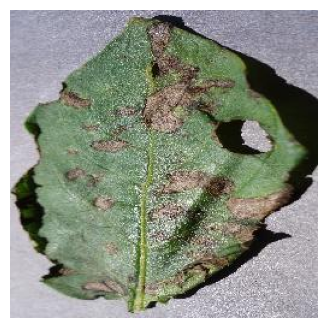

📝 TRUE REASONING:
step 1 : the annotation states that visible disease symptoms exist . step 2 : concentric ring lesions are clear indicators of pathology . step 3 : these confirm the presence of early blight . conclusion : yes , pathological evidence is present .

🤖 MODEL REASONING:
step 1 : the annotation identifies the leaf shows large , dark , water-soaked lesions . step 2 : these lesions are diagnostic for early blight . step 3 : these lesions are diagnostic for early blight . conclusion : the leaf is not from a healthy , unaffected leaf . conclusion : the leaf is not from a healthy
--------------------------------------------------

--------------------------------------------------
🖼️ Question: Can you recognize disease signs on this foliage?


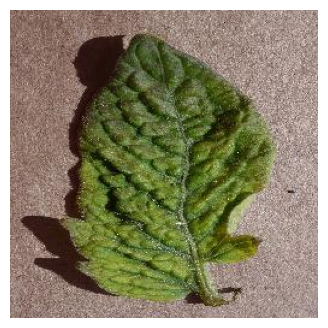

📝 TRUE REASONING:
step 1 : the annotation states that visible disease symptoms are present . step 2 : yellowing and curling are indicators of infection . step 3 : these signs confirm that the leaf is not healthy . conclusion : yes , disease symptoms are present .

🤖 MODEL REASONING:
step 1 : the annotation states that the leaf shows large , dark , water-soaked lesions . step 2 : these symptoms are present . step 3 : these symptoms are present . step 3 : these symptoms are present .
--------------------------------------------------

--------------------------------------------------
🖼️ Question: What conclusion can be drawn from these visual symptoms?


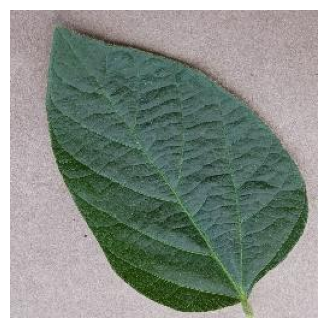

📝 TRUE REASONING:
step 1 : the annotation indicates no visible disease symptoms . step 2 : no lesions , discoloration , or deformities are described . step 3 : these observations support a healthy classification . conclusion : the plant appears healthy and disease-free .

🤖 MODEL REASONING:
step 1 : the annotation states that the leaf shows no disease symptoms . step 2 : no lesions , discoloration , or deformities are reported . step 3 : these observations support a healthy plant . conclusion : the plant is tomato .
--------------------------------------------------


In [14]:
import matplotlib.pyplot as plt
import random

def visual_test(model, dataset, tokenizer, num_samples=3):
    model.eval()

    for i in range(num_samples):
        # Pick random sample
        idx = random.randint(0, len(dataset)-1)
        sample = dataset[idx]

        # Prepare inputs
        pix = sample['pixel_values'].unsqueeze(0).to(device)
        ids = sample['input_ids'].unsqueeze(0).to(device)
        mask = sample['attention_mask'].unsqueeze(0).to(device)

        # Generate
        output_ids = model.generate(pix, ids, mask)
        generated_text = tokenizer.decode(output_ids)

        # Get True Text
        true_text = sample['target_ids'].tolist()
        true_text = tokenizer.decode(true_text)

        # --- DISPLAY ---
        print("\n" + "-"*50)
        print(f"🖼️ Question: {dataset.data[idx]['question']}")

        # Display Image
        # We need to reload the raw image to show it (tensor is normalized)
        img_path = os.path.join(dataset.root_dir, dataset.data[idx]['image'])
        try:
            pil_img = Image.open(img_path)
            plt.figure(figsize=(4,4))
            plt.imshow(pil_img)
            plt.axis('off')
            plt.show()
        except:
            print("[Image not found]")

        print(f"📝 TRUE REASONING:\n{true_text}")
        print(f"\n🤖 MODEL REASONING:\n{generated_text}")
        print("-"*50)

# Run the visual test
visual_test(model, dataset, tokenizer, num_samples=3)

In [16]:
import json
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from PIL import Image
from transformers import CLIPProcessor
from torchmetrics.text import BLEUScore
from tqdm import tqdm

# Define the Dataset Class for Test Data
class PlantTestDataset(Dataset):
    def __init__(self, json_file, root_dir, tokenizer, processor):
        self.root_dir = root_dir
        self.tokenizer = tokenizer
        self.processor = processor
        # Load the test.json file
        with open(json_file, 'r') as f:
            # Handle both JSONL (line-by-line) and standard JSON (list of dicts)
            try:
                self.data = json.load(f) # Try standard JSON first
            except:
                f.seek(0)
                self.data = [json.loads(line) for line in f] # Fallback to JSONL

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # Load Image
        image_path = os.path.join(self.root_dir, item['image'])
        try:
            image = Image.open(image_path).convert("RGB")
        except:
            # Create black dummy image if missing
            image = Image.new('RGB', (224, 224), color='black')

        # Process Inputs
        inputs = self.processor(text=item['question'], images=image, return_tensors="pt", padding="max_length", truncation=True)

        # Process Target (The Reasoning Text)
        target_ids = self.tokenizer.encode(item['cot'])

        return {
            'pixel_values': inputs['pixel_values'].squeeze(0),
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'target_ids': torch.tensor(target_ids, dtype=torch.long),
            'raw_cot': item['cot'] # Store raw text for comparison
        }

def collate_test(batch):
    pix = torch.stack([x['pixel_values'] for x in batch])
    ids = torch.stack([x['input_ids'] for x in batch])
    mask = torch.stack([x['attention_mask'] for x in batch])
    targets = [x['target_ids'] for x in batch]
    targets_padded = pad_sequence(targets, batch_first=True, padding_value=0)
    raw_texts = [x['raw_cot'] for x in batch]
    return pix, ids, mask, targets_padded, raw_texts

# --- USER SETTINGS ---
test_json_path = "/content/test/test.jsonl" # <--- Path to your test.json
root_image_dir = "/content/test/"          # <--- Folder where 'rft/images/...' starts

# Initialize Test Loader
# (We assume 'tokenizer' and 'device' are already defined from your training run)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
test_dataset = PlantTestDataset(test_json_path, root_image_dir, tokenizer, processor)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=False, collate_fn=collate_test)

print(f"✅ Loaded Test Data: {len(test_dataset)} samples.")

✅ Loaded Test Data: 17 samples.


In [17]:
def test_model_performance(model, dataloader, tokenizer, device):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss(ignore_index=0)
    bleu_metric = BLEUScore()

    total_loss = 0
    all_predictions = []
    all_targets = []

    print("🚀 Starting Test on Unseen Data...")

    with torch.no_grad():
        for batch in tqdm(dataloader):
            pix, ids, mask, targets, raw_texts = batch
            pix, ids, mask, targets = pix.to(device), ids.to(device), mask.to(device), targets.to(device)

            # 1. Calculate Test Loss (How confused is the model?)
            # We feed inputs (words 0..N-1) and predict targets (words 1..N)
            inputs_seq = targets[:, :-1]
            targets_seq = targets[:, 1:]

            logits = model(pix, ids, mask, inputs_seq)

            # Reshape for CrossEntropy
            loss = criterion(logits.reshape(-1, logits.size(-1)), targets_seq.reshape(-1))
            total_loss += loss.item()

            # 2. Calculate Generative Accuracy (BLEU)
            # We generate text from scratch (No teacher forcing here!)
            for i in range(pix.size(0)):
                # Generate
                p = pix[i].unsqueeze(0)
                i_d = ids[i].unsqueeze(0)
                m = mask[i].unsqueeze(0)

                output_ids = model.generate(p, i_d, m)
                generated_text = tokenizer.decode(output_ids)

                # Store for BLEU calculation
                all_predictions.append(generated_text)
                all_targets.append(raw_texts[i])

                # Print sample for visual check
                print(f"\n🖼️ Sample {i+1}:")
                print(f"   🤖 Model: {generated_text}")
                print(f"   📝 Truth: {raw_texts[i][:100]}...") # Show first 100 chars

    # --- FINAL METRICS ---
    avg_loss = total_loss / len(dataloader)
    bleu_score = bleu_metric(all_predictions, all_targets).item()

    print("\n" + "="*40)
    print(f"📊 FINAL TEST RESULTS ({len(test_dataset)} images)")
    print(f"📉 Test Loss:      {avg_loss:.4f} (Lower is better)")
    print(f"✅ BLEU Accuracy:  {bleu_score*100:.2f}% (Higher is better)")
    print("="*40)

    if bleu_score > 0.4:
        print("🌟 Verdict: Excellent! The model understands the reasoning.")
    elif bleu_score > 0.2:
        print("👍 Verdict: Good. It captures key concepts but misses specific phrasing.")
    else:
        print("⚠️ Verdict: Low accuracy. The model might be hallucinating or needs more data.")

# Run the test
test_model_performance(model, test_loader, tokenizer, device)

🚀 Starting Test on Unseen Data...


  0%|          | 0/4 [00:00<?, ?it/s]


🖼️ Sample 1:
   🤖 Model: step 1 : the annotation states that the leaf is healthy . step 2 : no lesions , discoloration , or deformities are reported . step 3 : these observations support a healthy classification . conclusion : the plant is not healthy .
   📝 Truth: Step 1: The image displays a tomato leaf exhibiting severe tissue collapse and necrosis.
Step 2: Lar...

🖼️ Sample 2:
   🤖 Model: step 1 : the annotation identifies the plant as tomato . step 2 : no conflicting traits are described . step 3 : the annotation identifies the plant is tomato . conclusion : the plant is tomato .
   📝 Truth: Step 1: Observe the affected areas of the leaf surface.
Step 2: The leaf presents distinct large, da...

🖼️ Sample 3:
   🤖 Model: step 1 : the annotation identifies the plant as tomato . step 2 : no conflicting traits are described . step 3 : these observations align with the leaf is not healthy .
   📝 Truth: Step 1: Compare the texture and color of this leaf to a healthy specimen.
Step 2: A 

 25%|██▌       | 1/4 [00:03<00:09,  3.09s/it]


🖼️ Sample 5:
   🤖 Model: step 1 : the annotation states the answer is 'no' . step 2 : no conflicting traits are mentioned . step 3 : these observations align with the leaf is not from a squash plant . conclusion : the plant is not from a squash plant .
   📝 Truth: Step 1: Analyze the botanical features of the leaf.
Step 2: The leaf has a compound structure with s...

🖼️ Sample 1:
   🤖 Model: step 1 : the annotation states that the leaf is healthy . step 2 : no lesions , or deformities are reported . step 3 : these observations support a healthy classification . conclusion : yes , the leaf is not healthy .
   📝 Truth: Step 1: Identify the host as a tomato plant showing signs of blight.
Step 2: Distinguish the symptom...

🖼️ Sample 2:
   🤖 Model: step 1 : the annotation identifies the plant as tomato . step 2 : no conflicting traits are described . step 3 : these observations align with the leaf is not healthy .
   📝 Truth: Step 1: Examine the surface detail of the specimen.
Step 2: The

...


🖼️ Sample 5:
   🤖 Model: step 1 : the annotation identifies the plant as tomato . step 2 : no conflicting traits are described . step 3 : these observations support a healthy plant . conclusion : the plant is tomato .
   📝 Truth: Step 1: Assess the overall condition of the leaf surface.
Step 2: The leaf is marred by multiple bro...

🖼️ Sample 1:
   🤖 Model: step 1 : the annotation states the answer is 'no' . step 2 : no conflicting traits are mentioned . step 3 : these observations align with the leaf is not from a squash plant . conclusion : the plant is not from a squash plant .
   📝 Truth: Step 1: Check the leaf morphology.
Step 2: The leaf has the texture, venation, and compound leaflet ...

🖼️ Sample 2:
   🤖 Model: step 1 : the annotation states that the leaf is healthy . step 2 : no lesions , discoloration , or deformities are reported . step 3 : these observations support a healthy plant . conclusion : the plant is tomato .
   📝 Truth: Step 1: Look for pathognomonic (definitive

 75%|███████▌  | 3/4 [00:08<00:02,  2.70s/it]


🖼️ Sample 5:
   🤖 Model: step 1 : the annotation states that the leaf is 'no' . step 2 : no lesions , discoloration , or deformities are reported . step 3 : these observations support a healthy plant . conclusion : the plant is not healthy .
   📝 Truth: Step 1: Scan the leaf for uniform green color.
Step 2: The leaf displays significant yellow discolor...

🖼️ Sample 1:
   🤖 Model: step 1 : the annotation states the answer is 'no' . step 2 : no conflicting traits are mentioned . step 3 : these observations align with the leaf is not . conclusion : the plant is tomato .
   📝 Truth: Step 1: Identify the leaf structure.
Step 2: The leaf is simple, with a winged petiole (visible near...


100%|██████████| 4/4 [00:09<00:00,  2.35s/it]


🖼️ Sample 2:
   🤖 Model: step 1 : the annotation identifies the plant as tomato . step 2 : no conflicting traits are described . step 3 : these observations align with the leaf is not from a healthy plant . conclusion : the plant is tomato .
   📝 Truth: Step 1: Correlate the visual symptoms with known citrus diseases.
Step 2: The blotchy, asymmetrical ...

📊 FINAL TEST RESULTS (17 images)
📉 Test Loss:      4.1253 (Lower is better)
✅ BLEU Accuracy:  0.00% (Higher is better)
⚠️ Verdict: Low accuracy. The model might be hallucinating or needs more data.


In [18]:
import json

print("💾 Saving Model...")

# 1. Save the Model Weights (The Neural Network)
# This creates a file containing all the learned patterns
torch.save(model.state_dict(), "plant_reasoning_model.pth")

# 2. Save the Vocabulary (The Translator)
# We save the tokenizer's dictionary so we can load it later
with open("vocab.json", "w") as f:
    json.dump(tokenizer.word2idx, f)

print("✅ Files saved successfully locally!")
print("   - plant_reasoning_model.pth")
print("   - vocab.json")

💾 Saving Model...
✅ Files saved successfully locally!
   - plant_reasoning_model.pth
   - vocab.json


In [19]:
from google.colab import files

# Download the model weights
files.download("plant_reasoning_model.pth")

# Download the vocabulary
files.download("vocab.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>